<a href="https://colab.research.google.com/github/Devraj-Sharma-2005/1st-project/blob/main/M.P%20rice%20yield%20production%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Load dataset
df = pd.read_csv('rice.csv')

# 2. Select the 18 essential features
selected_features = [
    'year', 'state', 'district', 'rice_yield_kgha',
    'rain_monsoon_mm', 'rain_annual_mm', 'tmax_monsoon', 'tmin_monsoon',
    'water_stress_score', 'lgp_days', 'n_per_ha_nca', 'p_per_ha_nca',
    'k_per_ha_nca', 'irrig_canal_area_1000ha', 'irrig_tubewell_area_1000ha',
    'soil_loamy_alfisols', 'soil_vertisols', 'soil_inceptisols', 'soil_sandy_alfisols'
]

# 3. Automated Data Cleaning & Handling Missing Values
clean_df = df[selected_features].dropna(subset=['rice_yield_kgha'])
clean_df = clean_df.fillna(clean_df.median(numeric_only=True))

# 4. Separate Features (X) and Target (Y)
X = clean_df.drop(columns=['rice_yield_kgha'])
y = clean_df['rice_yield_kgha']

# 5. One-Hot Encode categorical variables ('state', 'district')
X_encoded = pd.get_dummies(X, columns=['state', 'district'], drop_first=True)

# 6. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 7. Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# 8. Train & Evaluate Models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Model": name, "R2 Score": round(r2, 4), "RMSE": round(rmse, 2), "MAE": round(mae, 2)})

# 9. Print Results Table
results_df = pd.DataFrame(results)
print("--- MODEL PERFORMANCE COMPARISON ---")
print(results_df.to_string(index=False))

# 10. Export Cleaned Dataset to CSV for local backup
clean_df.to_csv('cleaned_rice_dataset.csv', index=False)
print("\nCleaned dataset exported successfully as 'cleaned_rice_dataset.csv'!")

--- MODEL PERFORMANCE COMPARISON ---
            Model  R2 Score   RMSE    MAE
Linear Regression    0.8367 358.22 248.90
    Random Forest    0.8807 306.15 214.15
          XGBoost    0.8812 305.52 220.42

Cleaned dataset exported successfully as 'cleaned_rice_dataset.csv'!


/tmp/ipykernel_1102/1852232975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")


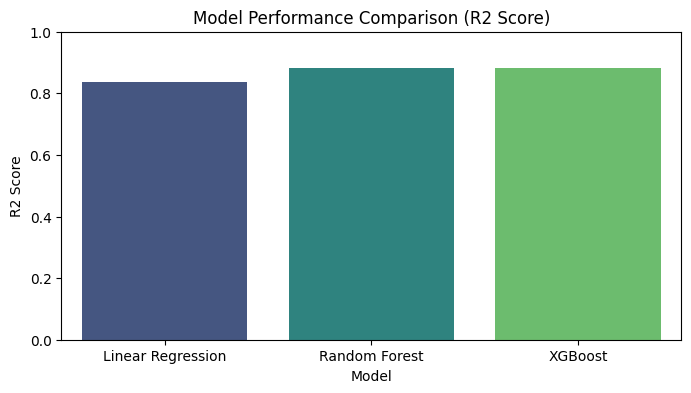

/tmp/ipykernel_1102/1852232975.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')


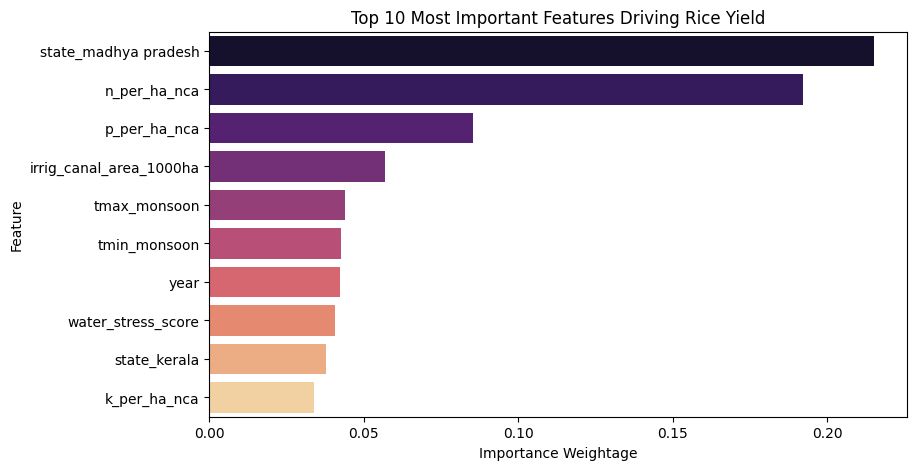

In [2]:
# 1. Plot Model Comparison (R2 Score)
plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")
plt.title("Model Performance Comparison (R2 Score)")
plt.ylim(0, 1)
plt.ylabel("R2 Score")
plt.show()

# 2. Plot Top 10 Feature Importances (Weightage Analysis)
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')
plt.title('Top 10 Most Important Features Driving Rice Yield')
plt.xlabel('Importance Weightage')
plt.show()

In [3]:
# Save trained Random Forest model
joblib.dump(models["Random Forest"], "best_rice_yield_model.pkl")
print("Saved best_rice_yield_model.pkl successfully!")

Saved best_rice_yield_model.pkl successfully!
